## Comparación de modelos de detección de anomalías y preparación del modelo a implementar

## Configuración y carga

In [11]:
import os
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import spearmanr
from pathlib import Path


from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score, precision_recall_curve

warnings.filterwarnings("ignore")
np.random.seed(42)

REPO = Path.cwd().parent.parent
PROCESSED_DIR = REPO / "data" / "processed"
FIG_DIR = REPO / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_START = pd.Timestamp("2025-04-01")

# --- Parametros de diseno (todos se someten a analisis de sensibilidad en la seccion 14)
LABEL_Q = 0.98        # cuantil que define la etiqueta proxy
ALERT_RATE = 0.01     # tasa de alerta objetivo, comun a todos los detectores
WIN_SCALE = 720       # ventana de la escala movil: 30 dias
MINP_SCALE = 240      # historia minima para estimar escala: 10 dias

# Paleta consistente en todo el notebook
C = {"mtr": "#c0392b", "mda": "#2980b9", "label": "#e67e22", "grid": "#bdc3c7",
     "M1": "#2980b9", "M2": "#c0392b", "M3": "#27ae60", "M4": "#8e44ad", "M5": "#d35400"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})

mtr = pd.read_csv(f"{PROCESSED_DIR}/monclova_features_mtr.csv", parse_dates=["timestamp"])
mda = pd.read_csv(f"{PROCESSED_DIR}/monclova_features_mda.csv", parse_dates=["timestamp"])

NODES = sorted(mtr["node_id"].unique())
REF_NODE = "06MON-115" if "06MON-115" in NODES else NODES[0]

print(f"MTR: {len(mtr):,} filas | MDA: {len(mda):,} filas | {len(NODES)} nodos")
print(f"Rango: {mtr['timestamp'].min():%Y-%m-%d} a {mtr['timestamp'].max():%Y-%m-%d}")
print(f"Nodo de referencia para graficas: {REF_NODE}")

MTR: 118,152 filas | MDA: 118,152 filas | 9 nodos
Rango: 2024-01-01 a 2025-06-30
Nodo de referencia para graficas: 06MON-115


## preparación, separación train-test


In [12]:
mda_ref = mda[["node_id", "timestamp", "pml", "mda_imputed"]].rename(
    columns={"pml": "pml_mda", "mda_imputed": "mda_was_imputed"})

panel = (mtr.drop(columns=["mda_imputed"], errors="ignore")
         .merge(mda_ref, on=["node_id", "timestamp"], how="inner", validate="one_to_one")
         .sort_values(["node_id", "timestamp"]).reset_index(drop=True))

panel["is_test"] = panel["timestamp"] >= TEST_START

n_h = panel.groupby("node_id").size().iloc[0]
print(f"Panel: {len(panel):,} filas = {len(NODES)} nodos x {n_h:,} horas")
print(f"Filas con MDA imputado: {int(panel['mda_was_imputed'].sum())} "
      f"({int(panel['mda_was_imputed'].sum()) // len(NODES)} horas x {len(NODES)} nodos, "
      f"{panel['mda_was_imputed'].mean():.2%} del total)")
print("\nParticion temporal:")
print(panel.groupby("is_test").agg(desde=("timestamp", "min"), hasta=("timestamp", "max"),
                                   filas=("timestamp", "size"),
                                   horas_por_nodo=("timestamp", lambda s: s.nunique())).to_string())

Panel: 118,152 filas = 9 nodos x 13,128 horas
Filas con MDA imputado: 252 (28 horas x 9 nodos, 0.21% del total)

Particion temporal:
             desde               hasta  filas  horas_por_nodo
is_test                                                      
False   2024-01-01 2025-03-31 23:00:00  98496           10944
True    2025-04-01 2025-06-30 23:00:00  19656            2184


## ¡Cómo evaluar una anomalía sin etiquetas?


### Etiqueta diferencia  MDA↔MTR 
El MDA es la expectativa publicada del mercado; el MTR es el valor real. La anomalía se define
como la divergencia entre ambas.



## 5. Construcción de la etiqueta 

**Paso 1 — log1p** `signed_log1p(MTR) − signed_log1p(MDA)`. La escala logarítmica hace
la medida relativa: +200 $/MWh sobre una base de 300 pesa mucho más que sobre una base de 5,000.
Se usa `signed_log1p` y no un cociente porque el MDA tiene valores negativos donde un cociente
cambiaría de signo o explotaría.

**Paso 2 — ajuste.** Se resta la mediana del logp1 por hora del día. Sin
esto, las horas con divergencia estructuralmente mayor (rampas de anochecer) dominarían la
etiqueta.

**Paso 3 — Escala móvil causal.** Se divide entre una MAD móvil de 30 días, calculada solo con datos anteriores a cada hora.

**Paso 4 — Umbral.** Identificación de un umbral para identificar anomalías

In [13]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


def causal_rolling_mad(x, window=WIN_SCALE, min_periods=MINP_SCALE):
    """
    MAD movil estrictamente causal: la fila t usa [t-window, t-1], nunca t.

    Se implementa con sliding_window_view en vez de rolling().apply() porque
    118k filas x 720 de ventana x 9 nodos con una lambda de Python es prohibitivo
    (minutos vs. segundos).
    """
    prev = np.concatenate(([np.nan], x[:-1]))
    n = len(prev)
    med = np.full(n, np.nan)
    mad = np.full(n, np.nan)
    if n >= window:
        w = sliding_window_view(prev, window)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = np.nanmedian(w, axis=1)
            d = np.nanmedian(np.abs(w - m[:, None]), axis=1)
        valid = (~np.isnan(w)).sum(axis=1) >= min_periods
        m[~valid] = np.nan
        d[~valid] = np.nan
        med[window - 1:] = m
        mad[window - 1:] = d
    return med, mad


def scale_causal(x):
    """Devuelve la escala robusta movil (sigma equivalente), con ceros neutralizados."""
    _, mad = causal_rolling_mad(x)
    s = mad * 1.4826
    return np.where((s == 0) | np.isnan(s), np.nan, s)


# Paso 1
panel["surprise"] = signed_log1p(panel["pml"]) - signed_log1p(panel["pml_mda"])
scope0 = ~panel["mda_was_imputed"]

# Paso 2
panel["surprise_dh"] = np.nan
for node in NODES:
    m = panel["node_id"] == node
    sub = panel.loc[m]
    med_h = sub.loc[scope0[m]].groupby("hora_dia")["surprise"].median()
    panel.loc[m, "surprise_dh"] = (sub["surprise"] - sub["hora_dia"].map(med_h)).values

# Paso 3
panel["surprise_z"] = np.nan
for node in NODES:
    m = panel["node_id"] == node
    sub = panel.loc[m].sort_values("timestamp")
    x = sub["surprise_dh"].values
    panel.loc[sub.index, "surprise_z"] = x / scale_causal(x)

# Paso 4
LABEL_SCOPE = scope0 & panel["surprise_z"].notna()
THRESH = panel.loc[LABEL_SCOPE, "surprise_z"].abs().quantile(LABEL_Q)
panel["label"] = ((panel["surprise_z"].abs() > THRESH) & LABEL_SCOPE).astype(int)

print(f"Umbral |z| = {THRESH:.2f} (cuantil {LABEL_Q} sobre todo el periodo)")
print(f"Filas sin escala movil (arranque de serie): "
      f"{int((~panel['surprise_z'].notna()).sum()):,}")
print("\nTasa de etiquetado:")
print(panel.groupby("is_test")["label"].agg(["sum", "mean"]).rename(
    columns={"sum": "filas", "mean": "tasa"}).to_string())

tl = panel[(panel["is_test"]) & (panel["label"] == 1)]
print(f"\nDireccion en test ({len(tl)} filas = {len(tl)//len(NODES)} horas x {len(NODES)} nodos):")
print(f"  MTR ENCIMA de lo esperado: {(tl['surprise_z'] > 0).sum():>4} filas")
print(f"  MTR DEBAJO  de lo esperado: {(tl['surprise_z'] < 0).sum():>4} filas")

Umbral |z| = 5.53 (cuantil 0.98 sobre todo el periodo)
Filas sin escala movil (arranque de serie): 6,471

Tasa de etiquetado:
         filas      tasa
is_test                 
False     2048  0.020793
True       183  0.009310

Direccion en test (183 filas = 20 horas x 9 nodos):
  MTR ENCIMA de lo esperado:  174 filas
  MTR DEBAJO  de lo esperado:    9 filas



## Detectores

Se eligieron cinco métodos

| Método | Familia | Qué captura bien | 
|---|---|---|
| **M1** Residual robusto | Estadístico local | Desviaciones respecto al patrón reciente de la misma hora |
| **M2** Isolation Forest | Ensamble, multivariado | Combinaciones raras de features aunque cada uno sea normal | 
| **M3** Naive estacional | Baseline trivial | Rupturas fuertes del patrón semanal | 
| **M4** Residual MSTL | Descomposición | Anomalías tras remover doble estacionalidad explícita | 


Los cinco operan sobre la serie MTR.


### M1 — Residual robusto

La referencia es la mediana de los lags de misma hora (t−24, t−48, t−72, t−168). Es una
desestacionalización implícita: compara cada hora contra cómo se comportó esa misma hora en días
recientes. L

El residual se escala con la MAD móvil causal.

In [14]:
SAME_HOUR_LAGS = ["pml_lag24", "pml_lag48", "pml_lag72", "pml_lag168"]

panel["m1_ref"] = panel[SAME_HOUR_LAGS].median(axis=1)
panel["m1_resid"] = panel["pml"] - panel["m1_ref"]
panel["m1_score"] = np.nan
for node in NODES:
    m = panel["node_id"] == node
    sub = panel.loc[m].sort_values("timestamp")
    x = sub["m1_resid"].values
    panel.loc[sub.index, "m1_score"] = np.abs(x / scale_causal(x))


### M2 — Isolation Forest 

Aísla observaciones en árboles aleatorios.


In [15]:
eps = 1e-6
panel["f_ratio_roll24"] = np.log((panel["pml"] + eps) / (panel["pml_roll24_mean"] + eps))
panel["f_ratio_roll168"] = np.log((panel["pml"] + eps) / (panel["pml_roll168_mean"] + eps))
panel["f_ratio_lag24"] = np.log((panel["pml"] + eps) / (panel["pml_lag24"] + eps))
panel["f_ratio_lag168"] = np.log((panel["pml"] + eps) / (panel["pml_lag168"] + eps))
panel["f_delta1"] = (panel["pml"] - panel["pml_lag1"]) / (panel["pml_roll24_mean"] + eps)
panel["f_vol_local"] = panel["pml_roll24_std"] / (panel["pml_roll24_mean"] + eps)
panel["f_vol_ratio"] = (panel["pml_roll24_std"] + eps) / (panel["pml_roll168_std"] + eps)

FEATURES = ["f_ratio_roll24", "f_ratio_roll168", "f_ratio_lag24", "f_ratio_lag168",
            "f_delta1", "f_vol_local", "f_vol_ratio",
            "hora_sin", "hora_cos", "dow_sin", "dow_cos"]

panel["m2_score"] = np.nan
for node in NODES:
    m = panel["node_id"] == node
    sub = panel.loc[m].sort_values("timestamp")
    X = sub[FEATURES].replace([np.inf, -np.inf], np.nan)
    ok = X.notna().all(axis=1)
    Xtr = X.loc[ok & (~sub["is_test"])]

    iso = IsolationForest(n_estimators=300, contamination=ALERT_RATE,
                          max_samples=min(4096, len(Xtr)), random_state=42,
                          n_jobs=-1).fit(Xtr)
    # score_samples: mas negativo = mas anomalo. Se invierte para homogeneizar orientacion.
    panel.loc[sub.index[ok.values], "m2_score"] = -iso.score_samples(X.loc[ok])


### M3 — Residual estacional (semanal)

`PML(t) − PML(t−168)`: comparar cada hora contra la misma hora de la semana anterior.


In [16]:
panel["m3_resid"] = panel["pml"] - panel["pml_lag168"]
panel["m3_score"] = np.nan
for node in NODES:
    m = panel["node_id"] == node
    sub = panel.loc[m].sort_values("timestamp")
    x = sub["m3_resid"].values
    panel.loc[sub.index, "m3_score"] = np.abs(x / scale_causal(x))

### M4 — Residual de descomposición MSTL

STL descompone la serie en tendencia, estacionalidad y residual. MSTL trabaja con varias estacionalidades, semanal y diaria



In [17]:
from statsmodels.tsa.seasonal import MSTL

panel["m4_resid"] = np.nan
panel["m4_score"] = np.nan

for node in NODES:
    m = panel["node_id"] == node
    sub = panel.loc[m].sort_values("timestamp").copy()
    y = sub.set_index("timestamp")["pml_log"].asfreq("h").interpolate()

    y_tr = y[y.index < TEST_START]
    # robust=True es indispensable: sin ponderacion robusta los picos extremos se
    # absorben en tendencia y estacionalidad, y desaparecen del residual justo donde
    # se los quiere ver.
    res = MSTL(y_tr, periods=(24, 168), stl_kwargs={"robust": True}).fit()

    seas = pd.DataFrame(np.asarray(res.seasonal), index=y_tr.index,
                        columns=["s24", "s168"] if np.asarray(res.seasonal).ndim > 1 else ["s24"])
    if "s168" not in seas:
        seas["s168"] = 0.0

    # Plantillas estacionales: perfil por hora y por (dia de semana, hora)
    tpl24 = seas.groupby(seas.index.hour)["s24"].median()
    tpl168 = seas.groupby([seas.index.dayofweek, seas.index.hour])["s168"].median()

    idx = y.index
    s24_proj = pd.Series(idx.hour, index=idx).map(tpl24).values
    s168_proj = pd.Series(list(zip(idx.dayofweek, idx.hour)), index=idx).map(tpl168).values

    # Tendencia causal (mediana movil de 7 dias solo con el pasado)
    trend = y.shift(1).rolling(168, min_periods=48).median().values

    resid = y.values - trend - s24_proj - s168_proj
    resid = pd.Series(resid, index=idx).reindex(sub["timestamp"]).values

    panel.loc[sub.index, "m4_resid"] = resid
    panel.loc[sub.index, "m4_score"] = np.abs(resid / scale_causal(resid))


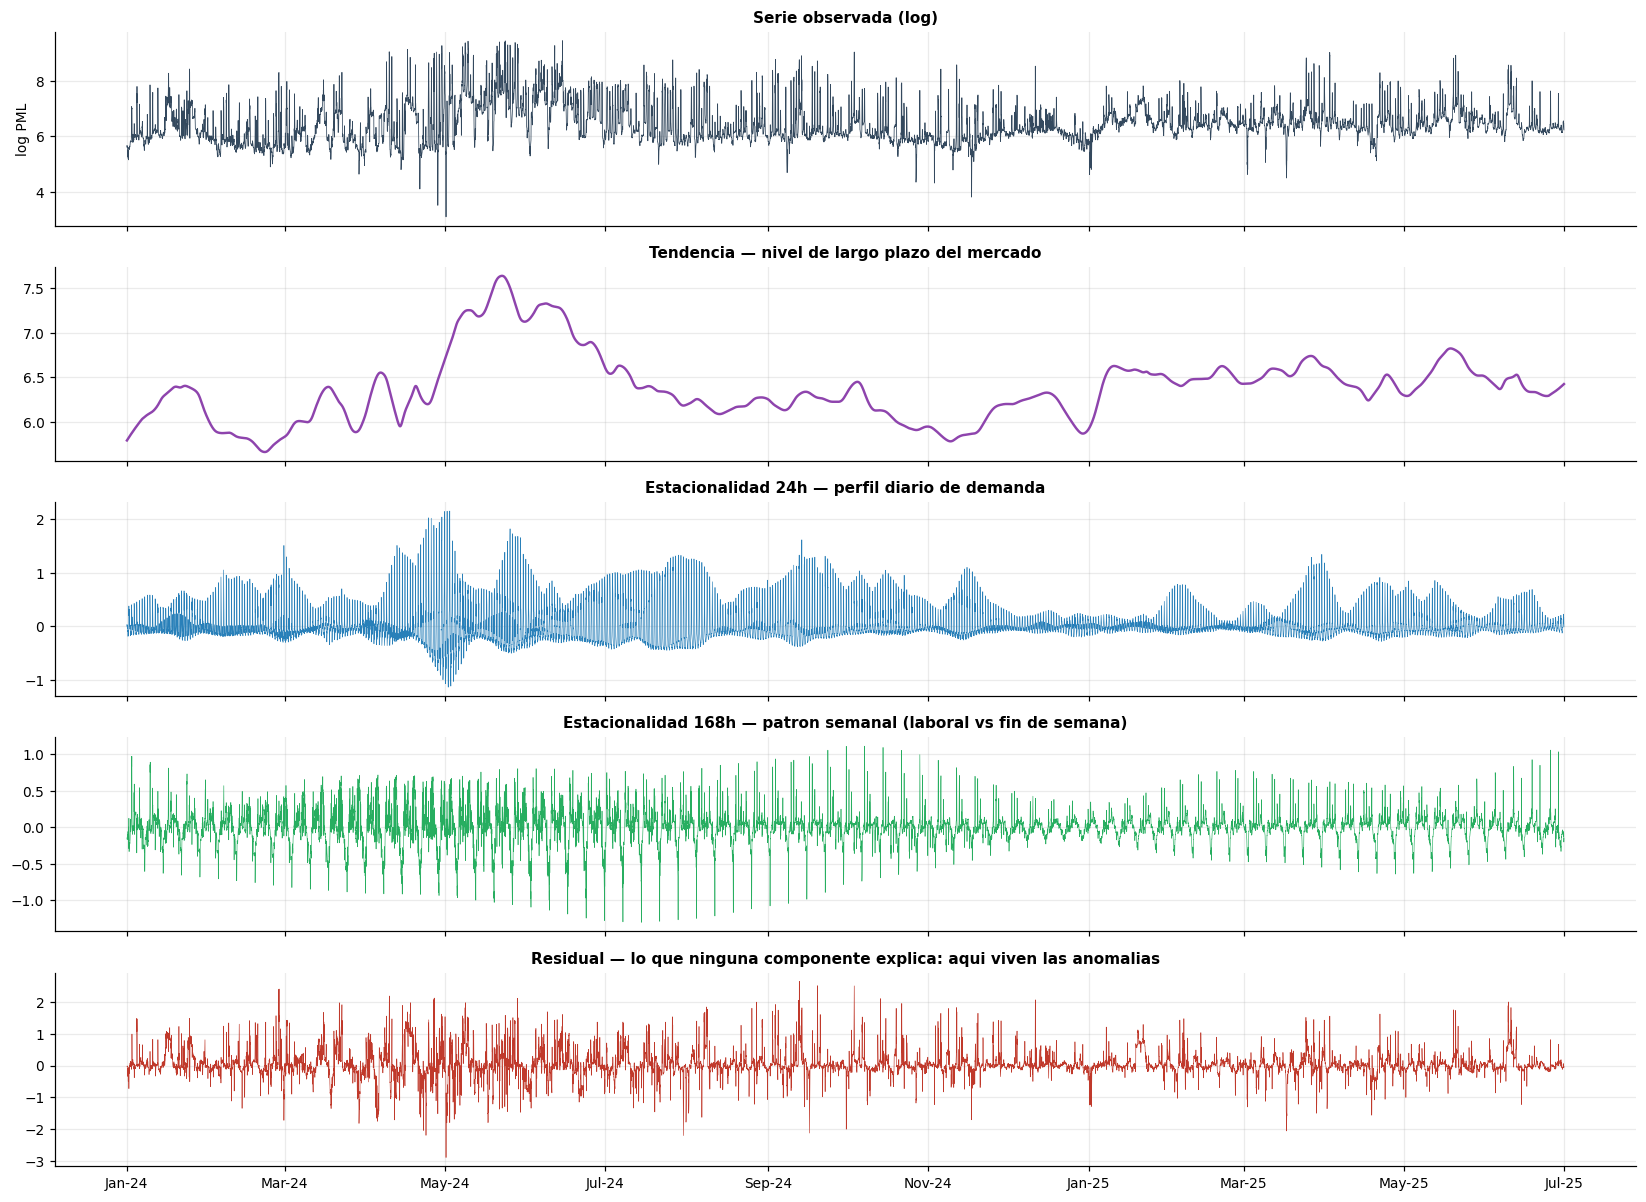

Varianza explicada por componente (nodo de referencia):
  Tendencia        :  33.1%
  Estacional 24h   :  19.3%
  Estacional 168h  :  11.3%
  Residual         :  36.2%


In [18]:
# Descomposicion MSTL completa del nodo de referencia: lamina explicativa para el deck.
# Aqui SI se ajusta sobre toda la serie porque el proposito es forense/ilustrativo,
# no de deteccion. El detector M4 usa la version causal de la celda anterior.
y_full = (panel[panel["node_id"] == REF_NODE].set_index("timestamp")["pml_log"]
          .asfreq("h").interpolate())
dec = MSTL(y_full, periods=(24, 168), stl_kwargs={"robust": True}).fit()
S = np.asarray(dec.seasonal)

fig, axes = plt.subplots(5, 1, figsize=(15, 11), sharex=True)
axes[0].plot(y_full.index, y_full.values, color="#34495e", lw=0.5)
axes[0].set_title("Serie observada (log)"); axes[0].set_ylabel("log PML")
axes[1].plot(y_full.index, dec.trend, color=C["M4"], lw=1.6)
axes[1].set_title("Tendencia — nivel de largo plazo del mercado")
axes[2].plot(y_full.index, S[:, 0], color=C["M1"], lw=0.4)
axes[2].set_title("Estacionalidad 24h — perfil diario de demanda")
axes[3].plot(y_full.index, S[:, 1] if S.ndim > 1 and S.shape[1] > 1 else np.zeros(len(y_full)),
             color=C["M3"], lw=0.4)
axes[3].set_title("Estacionalidad 168h — patron semanal (laboral vs fin de semana)")
axes[4].plot(y_full.index, dec.resid, color=C["mtr"], lw=0.4)
axes[4].set_title("Residual — lo que ninguna componente explica: aqui viven las anomalias")
axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/v2_descomposicion_mstl.png", dpi=200, bbox_inches="tight")
plt.show()

var_tot = np.var(y_full.values)
print("Varianza explicada por componente (nodo de referencia):")
print(f"  Tendencia        : {np.var(dec.trend)/var_tot:6.1%}")
print(f"  Estacional 24h   : {np.var(S[:, 0])/var_tot:6.1%}")
if S.ndim > 1 and S.shape[1] > 1:
    print(f"  Estacional 168h  : {np.var(S[:, 1])/var_tot:6.1%}")
print(f"  Residual         : {np.var(dec.resid)/var_tot:6.1%}")

In [19]:

METHODS = {"M1_residual_robusto": "m1_score",
           "M2_isolation_forest": "m2_score",
           "M3_naive_168h": "m3_score",
           "M4_mstl_residual": "m4_score"}
MCOL = {"M1_residual_robusto": C["M1"], "M2_isolation_forest": C["M2"],
        "M3_naive_168h": C["M3"], "M4_mstl_residual": C["M4"]}

In [ ]:
# Umbralizacion: convierte cada score continuo en una etiqueta binaria.
#
# El umbral es el cuantil correspondiente a la tasa de alerta objetivo, calculado
# por nodo y SOLO con datos de train. Fijar la MISMA tasa para todos los metodos
# es lo que hace comparables sus precision y recall: con umbrales independientes,
# la comparacion premiaria automaticamente al mas permisivo.
thresholds = {}
for name, col in METHODS.items():
    fc = col.replace("_score", "_flag")
    panel[fc] = 0
    for node in NODES:
        m = panel["node_id"] == node
        thr = panel.loc[m & (~panel["is_test"]), col].dropna().quantile(1 - ALERT_RATE)
        thresholds[(name, node)] = thr
        panel.loc[m, fc] = (panel.loc[m, col] > thr).fillna(False).astype(int)

flag_cols = [c.replace("_score", "_flag") for c in METHODS.values()]
panel["n_metodos"] = panel[flag_cols].sum(axis=1)

# El objeto 'test' debe reconstruirse DESPUES de crear los flags, o no los tendra
test = panel[panel["is_test"]].copy()

print(f"Tasa de alerta objetivo: {ALERT_RATE:.1%}\n")
for name, col in METHODS.items():
    fc = col.replace("_score", "_flag")
    print(f"  {name:<24} train={panel.loc[~panel['is_test'], fc].mean():.3%}  "
          f"test={panel.loc[panel['is_test'], fc].mean():.3%}")

Tasa de alerta objetivo: 1.0%

  M1_residual_robusto      train=0.941%  test=0.529%
  M2_isolation_forest      train=0.987%  test=0.392%
  M3_naive_168h            train=0.941%  test=0.458%
  M4_mstl_residual         train=0.941%  test=0.275%


##  Desempeño 

**hora a hora.** Precision, recall, F1 y PR-AUC hora por hora.

In [22]:
def point_metrics(y, f, s):
    ok = ~(pd.isna(s) | pd.isna(y))
    y, f, s = y[ok], f[ok], s[ok]
    tp = int(((f == 1) & (y == 1)).sum()); fp = int(((f == 1) & (y == 0)).sum())
    fn = int(((f == 0) & (y == 1)).sum())
    pr = tp / (tp + fp) if (tp + fp) else 0.0
    rc = tp / (tp + fn) if (tp + fn) else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "precision": pr, "recall": rc,
            "F1": 2 * pr * rc / (pr + rc) if (pr + rc) else 0.0,
            "PR_AUC": average_precision_score(y, s) if y.sum() > 0 else np.nan}




test = panel[panel["is_test"]].copy()

rows = []
for name, col in METHODS.items():
    fc = col.replace("_score", "_flag")
    for node in NODES:
        g = test[test["node_id"] == node]
        r = {"metodo": name, "nodo": node}
        r.update(point_metrics(g["label"].values, g[fc].values, g[col].values))
        rows.append(r)
e1 = pd.DataFrame(rows)

summary = e1.groupby("metodo").agg(
    precision=("precision", "mean"), recall=("recall", "mean"), F1=("F1", "mean"),
    PR_AUC=("PR_AUC", "mean")).round(4)

print("=" * 95)
print("DESEMPENO CONTRA ETIQUETA PROXY (test: abr-jun 2025, promedio de los 9 nodos)")
print("=" * 95)
print(summary.to_string())


DESEMPENO CONTRA ETIQUETA PROXY (test: abr-jun 2025, promedio de los 9 nodos)
                     precision  recall      F1  PR_AUC
metodo                                                
M1_residual_robusto     0.5202  0.2952  0.3765  0.4231
M2_isolation_forest     0.4691  0.1968  0.2772  0.3068
M3_naive_168h           0.2000  0.0984  0.1319  0.1630
M4_mstl_residual        0.8333  0.2460  0.3799  0.5313


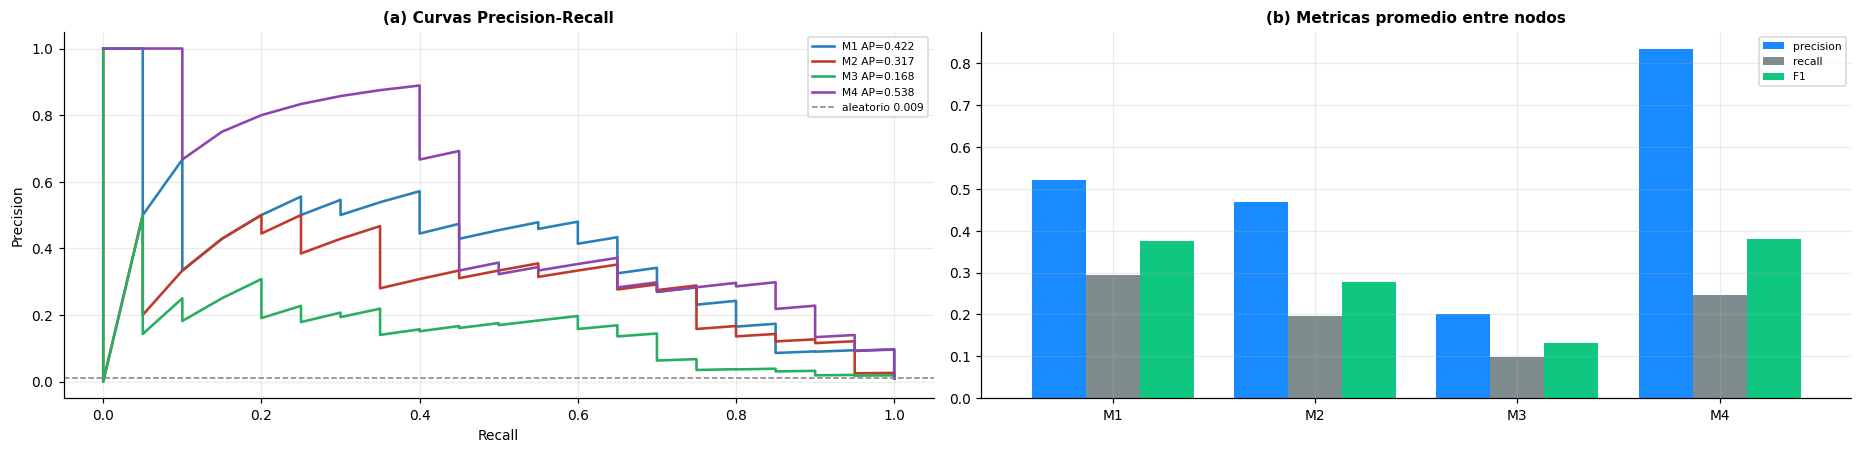

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(17, 4.2))

g = test[test["node_id"] == REF_NODE]
base = g["label"].mean()

# (a) Curvas PR
if g["label"].sum() > 0:
    for name, col in METHODS.items():
        ok = g[col].notna()
        p, r, _ = precision_recall_curve(g.loc[ok, "label"], g.loc[ok, col])
        ap = average_precision_score(g.loc[ok, "label"], g.loc[ok, col])
        axes[0].plot(r, p, lw=1.7, color=MCOL[name], label=f"{name[:2]} AP={ap:.3f}")
axes[0].axhline(base, color="gray", ls="--", lw=1, label=f"aleatorio {base:.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("(a) Curvas Precision-Recall"); axes[0].legend(fontsize=7)


# (b) Comparativa de metricas
piv = e1.groupby("metodo")[["precision", "recall", "F1"]].mean()
piv.plot(kind="bar", ax=axes[1], width=0.8,
         color=["#178bff", "#7f8c8d", "#0fc780", C["label"]])
axes[1].set_title("(b) Metricas promedio entre nodos")
axes[1].set_xticklabels([t.get_text()[:2] for t in axes[1].get_xticklabels()], rotation=0)
axes[1].set_xlabel(""); axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

### Observación
 **La etiqueta es una definición arbitraria.** Mide diferencia respecto al día en
   adelanto. Un evento que ambos mercados anticiparon no queda etiquetado aunque sea
   relevante. Es una elección deliberada: se detecta lo inesperado.

